# tap.ondes~ / tap.triode~ — the heterodyne voice, and the valves after it

The two last pieces of the Ondes Martenot, and the two the family plan got wrong before the
sources were read.

The plan assumed a `vco.h` descendant with waveform registers. The instrument is nothing of the
kind. It is **heterodyne**: two oscillators near 80 kHz, one fixed and one moved by the ribbon,
summed into an amplitude-modulated signal whose envelope is the note. Najnudel, Hélie, Roze &
Boutin (*"Simulation of an ondes Martenot circuit"*, IEEE/ACM TASLP **28**, 2651–2660, 2020)
model instrument No. 169 as five port-Hamiltonian stages and measure those oscillators at about
**0.03 % second-harmonic distortion** even coupled to the rest of the circuit. So the character is
not in the oscillators at all — it is in the demodulator, the two triode stages, the intensity
key and the diffuseur.

This notebook measures three things, in order of how much they changed the design:

1. **What the demodulator actually makes.** Not a sinusoid — the plan's biggest error.
2. **Whether the closed-form detector really replaces the 80 kHz simulation.** It does, to 0.10 dB.
3. **What the valves add**, from a published tube model with parameters fitted to the actual
   valves in No. 169.

Every number comes out of the shipping C++ through `tools/capi`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.4),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def goertzel(y, f, fs, frm=None):
    # single-bin magnitude, so a measurement never depends on FFT bin alignment
    if frm is None:
        frm = len(y) // 2
    seg = np.asarray(y[frm:], dtype=float)
    w = 2 * np.pi * f / fs
    c = 2 * np.cos(w)
    s1 = s2 = 0.0
    for v in seg:
        s1, s2 = v + c * s1 - s2, s1
    return np.sqrt(max(0.0, s1 * s1 + s2 * s2 - c * s1 * s2)) * 2 / len(seg)

def harmonics(y, f0, fs, n=5):
    h = np.array([goertzel(y, f0 * k, fs) for k in range(1, n + 1)])
    return h[0], 20 * np.log10(h[1:] / h[0])

print("tube parameter sets, from TASLP 28 (2020) Table II — fitted to ondes No. 169's own valves:")
for i, name in enumerate(tap.TUBE_NAMES):
    p = tap.tube_params(i)
    print(f"  {name}: " + "  ".join(f"{k}={v:g}" for k, v in p.items()))

tube parameter sets, from TASLP 28 (2020) Table II — fitted to ondes No. 169's own valves:
  6F5: mu=98  ex=1.6  kg=2614  kp=905  kvb=1.87  vct=0.5  va=0.33  rgk=1300
  6C5: mu=20  ex=1.5  kg=2837  kp=138  kvb=89  vct=0.8  va=0.33  rgk=1300
  2A3: mu=4.3  ex=1.5  kg=1685  kp=43  kvb=102  vct=-1.2  va=0.33  rgk=1300


## 1 · The demodulator is the instrument's biggest source of harmonics

The circuit paper writes the oscillator sum as an amplitude-modulated sinewave:

$$\cos\Phi + \cos(\Phi - \varphi) = 2\cos(\Phi - \varphi/2)\,\cos(\varphi/2)$$

so the envelope is $2|\cos(\varphi/2)|$ — and $|\cos|$ is emphatically **not** a sinusoid. Its
Fourier coefficients are $(4/\pi)/(4n^2-1)$, which puts the second harmonic 14.0 dB below the
fundamental, the third 21.3 dB down and the fourth 26.4 dB down.

That series exists **before any valve touches the signal**. The family plan said to synthesize the
difference tone directly as a sinusoid, citing the paper's own simplification — but what the paper
replaces with a sinewave generator is the *oscillators*, not the demodulator. Synthesizing the
difference tone would have thrown away the largest single contributor to the instrument's timbre.

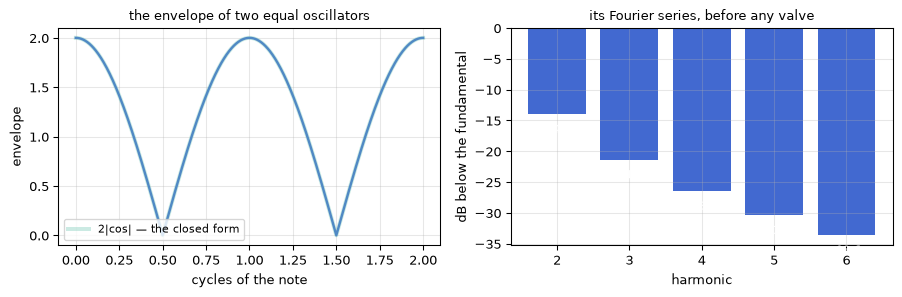

ideal |cos| series:  H2=-14.0 dB  H3=-21.3 dB  H4=-26.4 dB  H5=-30.4 dB  H6=-33.6 dB


In [2]:
# The envelope itself, out of the kernel, against the closed form's Fourier series.
det = tap.Detector(sr, frequency=220.0)
phase = np.linspace(0, 2, 801)
env = det.envelope(phase % 1.0)

ideal = np.array([(4 / np.pi) / (4 * n * n - 1) for n in range(1, 7)])
ideal_db = 20 * np.log10(ideal[1:] / ideal[0])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].plot(phase, env, color=C[0], lw=1.8)
axes[0].plot(phase, np.abs(np.cos(np.pi * phase)) * 2, color=C[3], lw=3.0, alpha=0.35,
             label="2|cos| — the closed form")
axes[0].set_xlabel("cycles of the note"); axes[0].set_ylabel("envelope")
axes[0].set_title("the envelope of two equal oscillators", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].bar(np.arange(2, 7), ideal_db, color=C[0])
for n, v in zip(range(2, 7), ideal_db):
    axes[1].annotate(f"{v:.1f}", (n, v), textcoords="offset points", xytext=(0, -14),
                     ha="center", fontsize=8, color="white")
axes[1].set_xlabel("harmonic"); axes[1].set_ylabel("dB below the fundamental")
axes[1].set_title("its Fourier series, before any valve", fontsize=10)
plt.tight_layout()
plt.show()

print("ideal |cos| series:  " + "  ".join(f"H{n}={v:+.1f} dB" for n, v in zip(range(2, 7), ideal_db)))

## 2 · The closed form really does replace the 80 kHz simulation

The kernel never generates a carrier. For amplitudes 1 and `depth` the envelope of
$\cos\Phi + d\cos(\Phi-\varphi)$ is exactly $\sqrt{1 + d^2 + 2d\cos\varphi}$, and the published
detector — a triode grid at near-zero bias conducting only on positive half-cycles, loaded by
$R_4C_{21} = 200\,\mu s$ — is run on *that*.

The claim needs checking against the thing it replaces, so this cell builds the expensive version:
two oscillators at 80 kHz and 80 kHz − f, summed, half-wave rectified, RC-loaded, at 3 MHz.

In [3]:
TAU = 0.2e-3   # R4 * C21 = 1 MOhm * 200 pF, TASLP Table II

def full_heterodyne(f, fs=3.0e6, carrier=80_000.0, cycles=60):
    n = int(fs * cycles / f)
    t = np.arange(n) / fs
    am = np.cos(2 * np.pi * carrier * t) + np.cos(2 * np.pi * (carrier - f) * t)
    a = np.exp(-1.0 / (TAU * fs))
    y = np.zeros(n)
    s = 0.0
    for i in range(n):
        v = am[i]
        s = v if v > s * a else s * a
        y[i] = s
    return y, fs

def closed_form(f, fs=384_000.0, cycles=60):
    d = tap.Detector(fs, frequency=f)
    return d.process(int(fs * cycles / f)), fs

rows = []
for f in (110.0, 440.0, 1760.0):
    yf, fsf = full_heterodyne(f)
    yc, fsc = closed_form(f)
    a1, adb = harmonics(yf, f, fsf, 4)
    b1, bdb = harmonics(yc, f, fsc, 4)
    rows.append((f, a1, b1, adb, bdb))

print(f"{'f':>7} {'H2 full':>9} {'H2 form':>9} {'H3 full':>9} {'H3 form':>9} "
      f"{'H4 full':>9} {'H4 form':>9} {'worst dB':>9} {'level':>8}")
for f, a1, b1, adb, bdb in rows:
    worst = np.max(np.abs(adb - bdb))
    print(f"{f:7.0f} " + " ".join(f"{adb[k]:9.2f} {bdb[k]:9.2f}" for k in range(3))
          + f" {worst:9.3f} {b1/a1:8.3f}")
print()
print("The harmonic ratios agree to within a tenth of a dB at every pitch. The one systematic")
print("difference is level: the closed form sits a few percent high, because a follower chasing")
print("real carrier half-cycles never quite reaches the peak between them.")

      f   H2 full   H2 form   H3 full   H3 form   H4 full   H4 form  worst dB    level
    110    -14.03    -14.02    -21.46    -21.46    -26.67    -26.67     0.006    1.030
    440    -14.69    -14.69    -23.23    -23.22    -29.90    -29.92     0.014    1.031
   1760    -19.32    -19.28    -23.10    -23.00    -28.38    -28.33     0.098    1.032

The harmonic ratios agree to within a tenth of a dB at every pitch. The one systematic
difference is level: the closed form sits a few percent high, because a follower chasing
real carrier half-cycles never quite reaches the peak between them.


### The detector is pitch-dependent, and that is the instrument, not a defect

The RC cannot follow a fast envelope back down, so as the note rises the notch between cycles gets
filled in: the tone gets purer *and* quieter with pitch. Both fall out of the same 200 µs.

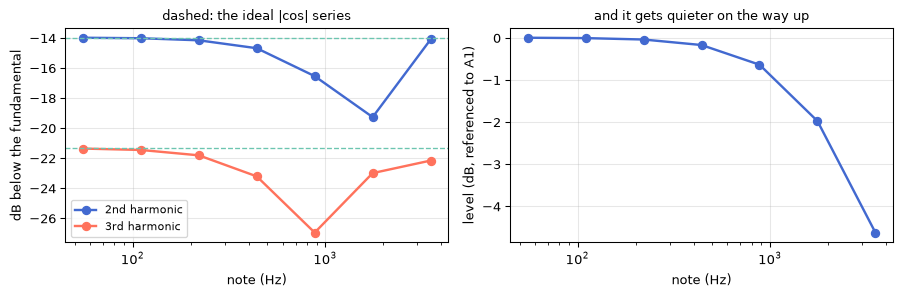

H2 at A2: -14.0 dB   at A6: -19.3 dB
level A2 -> A6: -2.0 dB


In [4]:
notes = np.array([55., 110., 220., 440., 880., 1760., 3520.])
h1, h2, h3 = [], [], []
for f in notes:
    y, fs = closed_form(f, cycles=60)
    a, db = harmonics(y, f, fs, 3)
    h1.append(a); h2.append(db[0]); h3.append(db[1])
h1 = np.array(h1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].semilogx(notes, h2, "o-", color=C[0], lw=1.8, label="2nd harmonic")
axes[0].semilogx(notes, h3, "o-", color=C[2], lw=1.8, label="3rd harmonic")
axes[0].axhline(-14.0, color=C[3], ls="--", lw=1.0)
axes[0].axhline(-21.3, color=C[3], ls="--", lw=1.0)
axes[0].set_xlabel("note (Hz)"); axes[0].set_ylabel("dB below the fundamental")
axes[0].set_title("dashed: the ideal |cos| series", fontsize=10); axes[0].legend(fontsize=8)

axes[1].semilogx(notes, 20 * np.log10(h1 / h1[0]), "o-", color=C[0], lw=1.8)
axes[1].set_xlabel("note (Hz)"); axes[1].set_ylabel("level (dB, referenced to A1)")
axes[1].set_title("and it gets quieter on the way up", fontsize=10)
plt.tight_layout()
plt.show()

print(f"H2 at A2: {h2[1]:.1f} dB   at A6: {h2[5]:.1f} dB")
print(f"level A2 -> A6: {20*np.log10(h1[5]/h1[1]):.1f} dB")

### Oscillator balance is a real knob

Nothing says the two oscillators must have equal amplitude. Unequal, the envelope never closes,
and the harmonic series thins out. It is the cheapest timbre control the object has, and it is
physical rather than invented — a mismatch between two real oscillators does exactly this.

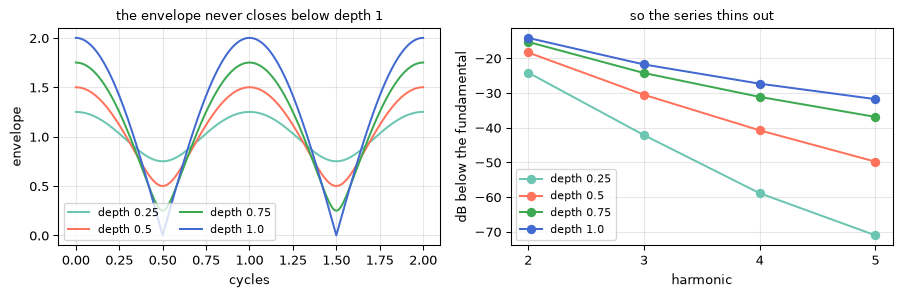

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
depths = [0.25, 0.5, 0.75, 1.0]
ph = np.linspace(0, 2, 801)
for d, colour in zip(depths, (C[3], C[2], C[4], C[0])):
    det = tap.Detector(sr, frequency=220.0, depth=d)
    axes[0].plot(ph, det.envelope(ph % 1.0), color=colour, lw=1.5, label=f"depth {d}")
    y = tap.Detector(384_000.0, frequency=220.0, depth=d).process(int(384_000.0 * 60 / 220.0))
    _, db = harmonics(y, 220.0, 384_000.0, 5)
    axes[1].plot(range(2, 6), db, "o-", color=colour, lw=1.5, label=f"depth {d}")
axes[0].set_xlabel("cycles"); axes[0].set_ylabel("envelope"); axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title("the envelope never closes below depth 1", fontsize=10)
axes[1].set_xlabel("harmonic"); axes[1].set_ylabel("dB below the fundamental")
axes[1].set_xticks(range(2, 6)); axes[1].legend(fontsize=8)
axes[1].set_title("so the series thins out", fontsize=10)
plt.tight_layout()
plt.show()

## 3 · The valves

The circuit paper models the triodes with the **enhanced Norman Koren** law (Koren, *Glass Audio*
8(5), 1996; grid-current branch from Cohen & Hélie, AES 129, 2010):

$$E_1 = \frac{v_{pc}}{K_p}\ln\!\left(1 + \exp\!\left(K_p\left(\tfrac{1}{\mu} +
\tfrac{v_{gc}+V_{ct}}{\sqrt{K_{vb}+v_{pc}^2}}\right)\right)\right), \qquad
i_{pc} = \frac{2E_1^{E_x}}{K_g}$$

and gives parameter sets **fitted to the valves actually in ondes No. 169** — 6F5 in the
oscillators, 6C5 in the demodulator and preamplifier, 2A3 in the power amplifier. Those, and the
stage supply voltages and cathode resistors, are the whole specification. Nothing in this kernel's
valve is voiced by ear.

First check: does the fitted 6C5 land on its datasheet's typical operating point? Tung-Sol's sheet
says 8 mA at 250 V on the plate and −8 V on the grid.

6C5 at Vp = 250 V, Vg = -8 V: 8.85 mA   (datasheet typical: 8 mA)


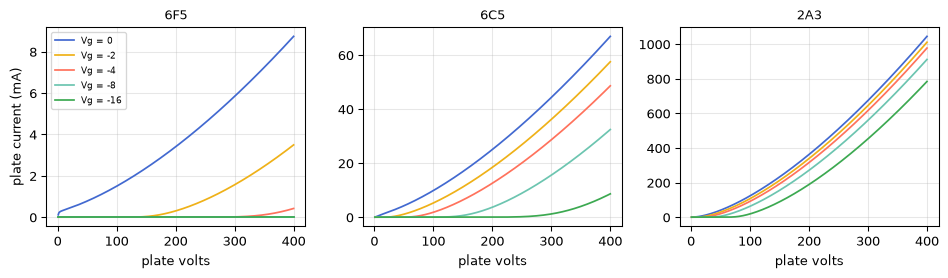

In [6]:
print(f"6C5 at Vp = 250 V, Vg = -8 V: {float(tap.tube_plate_current(tap.TUBE_6C5, 250., -8.))*1000:.2f} mA"
      f"   (datasheet typical: 8 mA)")

vp = np.linspace(1, 400, 400)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))
for ax, ti in zip(axes, (tap.TUBE_6F5, tap.TUBE_6C5, tap.TUBE_2A3)):
    for vg, colour in zip((0, -2, -4, -8, -16), (C[0], C[1], C[2], C[3], C[4])):
        ax.plot(vp, tap.tube_plate_current(ti, vp, float(vg)) * 1000, color=colour, lw=1.3,
                label=f"Vg = {vg}")
    ax.set_title(tap.TUBE_NAMES[ti], fontsize=10)
    ax.set_xlabel("plate volts")
axes[0].set_ylabel("plate current (mA)")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

### A stage is a load line, and the load line is asymmetric

Given the published supply, cathode resistor and plate load, the stage's operating point and its
transfer curve are just the solution of

$$i_{pc}(v_{pc}, v_{gc}) = \frac{V_{bias} - V_k - v_{pc}}{R_p}, \qquad V_k = R_k I_{pc}$$

which is a **memoryless nonlinearity** in the DAFx-07 sense (Yeh, Abel & Smith 2007) — the same
architecture `fuzz.h` uses, but with the curve coming from a fitted tube model instead of a tanh.
Tabulating it is not an approximation of the model; it *is* the model.

Two things to notice: the stage **inverts**, and it is **strongly asymmetric**. The asymmetry is
where a triode's even harmonics come from, and the inversion matters because it decides which side
of the waveform the asymmetry acts on.

               stage   Vbias      Vk      Vp0   Ip0 mA    gain
    6C5, demodulator     100    2.70    86.50     2.70    4.86
   6C5, preamplifier     180    4.95   155.26     4.95    5.56
      2A3, power amp     230   25.48   153.56    33.97    2.69


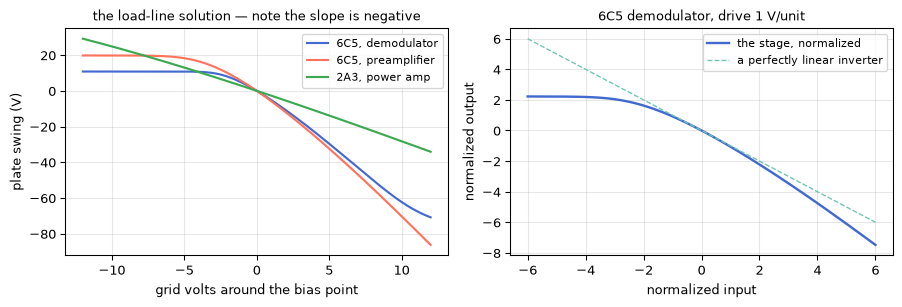

asymmetry at +-4 units of input: 4.754 one way, 2.191 the other — a ratio of 2.17


In [7]:
stages = [("6C5, demodulator", tap.TUBE_6C5, tap.OP_DEMOD),
          ("6C5, preamplifier", tap.TUBE_6C5, tap.OP_PREAMP),
          ("2A3, power amp", tap.TUBE_2A3, tap.OP_POWER)]

print(f"{'stage':>20} {'Vbias':>7} {'Vk':>7} {'Vp0':>8} {'Ip0 mA':>8} {'gain':>7}")
tri = {}
for name, ti, op in stages:
    t = tap.Triode(sr, ti, op, drive=1.0)
    tri[name] = t
    vk, vp0, ip0, g = t.bias
    print(f"{name:>20} {op[0]:7.0f} {vk:7.2f} {vp0:8.2f} {ip0*1000:8.2f} {g:7.2f}")

gv = np.linspace(-12, 12, 601)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))
for (name, _, _), colour in zip(stages, (C[0], C[2], C[4])):
    axes[0].plot(gv, tri[name].plate_swing(gv), color=colour, lw=1.6, label=name)
axes[0].set_xlabel("grid volts around the bias point"); axes[0].set_ylabel("plate swing (V)")
axes[0].set_title("the load-line solution — note the slope is negative", fontsize=10)
axes[0].legend(fontsize=8)

x = np.linspace(-6, 6, 601)
t = tri["6C5, demodulator"]
axes[1].plot(x, t.curve(x), color=C[0], lw=1.8, label="the stage, normalized")
axes[1].plot(x, -x, color=C[3], ls="--", lw=1.0, label="a perfectly linear inverter")
axes[1].set_xlabel("normalized input"); axes[1].set_ylabel("normalized output")
axes[1].set_title("6C5 demodulator, drive 1 V/unit", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

up, down = abs(float(t.curve(4.0))), abs(float(t.curve(-4.0)))
print(f"asymmetry at +-4 units of input: {up:.3f} one way, {down:.3f} the other — a ratio of {up/down:.2f}")

## 4 · The whole voice

Detector → demodulator triode → preamplifier triode → intensity key. The `drive` control is the
harmonics knob (the circuit paper's own plugin exposes demodulator input gain the same way, a knob
the real instrument does not have), and it is normalized so it changes the distortion rather than
the level — the gain-staging lesson `fuzz.h` learned the hard way, applied here from the start.

The measurement that matters: **at drive 0 the harmonics are already there**, because the
demodulator made them.

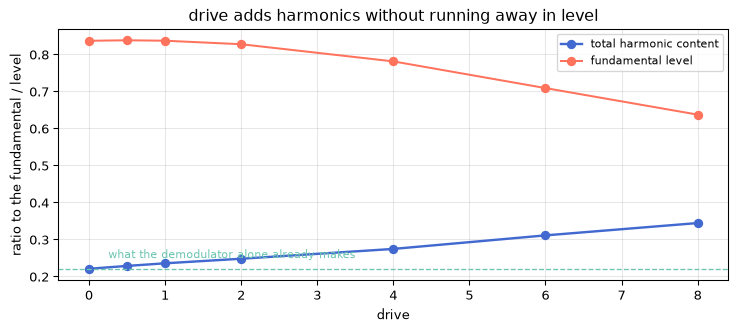

  drive  0.0: THD 0.221   H2  -14.1 dB
  drive  0.5: THD 0.228   H2  -13.8 dB
  drive  1.0: THD 0.236   H2  -13.5 dB
  drive  2.0: THD 0.248   H2  -12.9 dB
  drive  4.0: THD 0.274   H2  -11.6 dB
  drive  6.0: THD 0.311   H2  -10.3 dB
  drive  8.0: THD 0.344   H2   -9.3 dB


In [8]:
def voice_run(seconds=1.0, **kw):
    kw.setdefault("key", 1.0)
    v = tap.Ondes(sr, smooth_ms=0, level=1.0, **kw)
    return v.process(int(sr * seconds)), v.frequency

drives = [0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0]
thd, h1s, h2s = [], [], []
for d in drives:
    y, f0 = voice_run(ribbon=24.0, drive=d)
    h = np.array([goertzel(y, f0 * k, sr) for k in range(1, 11)])
    thd.append(np.sqrt((h[1:] ** 2).sum()) / h[0])
    h1s.append(h[0]); h2s.append(20 * np.log10(h[1] / h[0]))

fig, ax = plt.subplots()
ax.plot(drives, thd, "o-", color=C[0], lw=1.8, label="total harmonic content")
ax.plot(drives, np.array(h1s), "o-", color=C[2], lw=1.5, label="fundamental level")
ax.axhline(thd[0], color=C[3], ls="--", lw=1.0)
ax.annotate("what the demodulator alone already makes", (0.15, thd[0]),
            textcoords="offset points", xytext=(6, 8), fontsize=8, color=C[3])
ax.set_xlabel("drive"); ax.set_ylabel("ratio to the fundamental / level")
ax.set_title("drive adds harmonics without running away in level")
ax.legend(fontsize=8)
plt.show()

for d, t_, h in zip(drives, thd, h2s):
    print(f"  drive {d:4.1f}: THD {t_:.3f}   H2 {h:+6.1f} dB")

### The two choices the sources do not settle

The circuit paper's five stages **do not include the intensity key**, so where it sits in the chain
is a modelling decision; and the two triodes are coupled through a transformer whose winding sense
is not given, so the sign between them is another. Both are audible, so both are switches rather
than silent guesses.

In [9]:
def measure(**kw):
    y, f0 = voice_run(ribbon=24.0, **kw)
    h = np.array([goertzel(y, f0 * k, sr) for k in range(1, 11)])
    return np.sqrt((h[1:] ** 2).sum()) / h[0], h[0]

print("coupling polarity (drive 4, key full):")
for p in (1, -1):
    t_, h = measure(drive=4.0, polarity=p)
    print(f"   {p:+d}: THD {t_:.3f}   fundamental {h:.4f}")

print()
print("intensity key placement (drive 6, key 0.62 — a half-press):")
for name, kp in (("after the valves ", 0), ("before the valves", 1)):
    t_, h = measure(drive=6.0, key=0.62, key_placement=kp)
    print(f"   {name}: THD {t_:.3f}   fundamental {h:.4f}")
print("   Placed before, a half-pressed key drives the valves less hard — pressure becomes dirt,")
print("   which is a very different instrument to play even though neither reading is provably")
print("   the historical one.")

print()
print("the 2A3 power stage (drive 2), which the paper drops for real-time:")
for name, on in (("off", False), ("on ", True)):
    t_, h = measure(drive=2.0, power_stage=on)
    print(f"   {name}: THD {t_:.3f}   fundamental {h:.4f}")
print("   Their reason was that its contribution is much less important than the two stages")
print("   before it. Measured here, that is right: it barely moves.")

coupling polarity (drive 4, key full):
   +1: THD 0.274   fundamental 0.7810


   -1: THD 0.394   fundamental 0.8366

intensity key placement (drive 6, key 0.62 — a half-press):
   after the valves : THD 0.311   fundamental 0.0149


   before the valves: THD 0.222   fundamental 0.0176
   Placed before, a half-pressed key drives the valves less hard — pressure becomes dirt,
   which is a very different instrument to play even though neither reading is provably
   the historical one.

the 2A3 power stage (drive 2), which the paper drops for real-time:
   off: THD 0.248   fundamental 0.8274


   on : THD 0.251   fundamental 0.8245
   Their reason was that its contribution is much less important than the two stages
   before it. Measured here, that is right: it barely moves.


## 5 · Oversampling, and a data point for an open question

`fuzz.h` measured something awkward: alias energy at 4× came out *worse* than at 2×, and the
untested hypothesis it left behind was **imaging** — zero-stuffing by N leaves N−1 images for one
filter to suppress, and their residuals intermodulate in the clipper into products that are not
harmonics of the input.

`tap.ondes~` is a **source**. Nothing is zero-stuffed on the way up; the detector simply runs fast,
so there are no images at all. If the imaging hypothesis is right, the sequence here should behave —
and the test is whether it ever *reverses*, which is the thing that needed explaining.

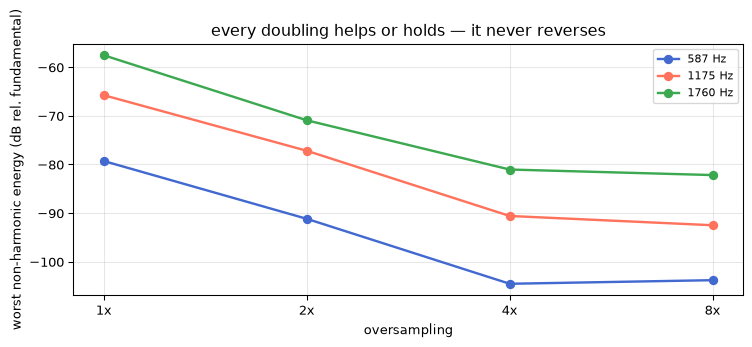

    587.3 Hz:  -79.3   -91.2  -104.5  -103.8
   1174.7 Hz:  -65.8   -77.2   -90.6   -92.5
   1760.0 Hz:  -57.6   -70.9   -81.1   -82.2
   2637.0 Hz:  -51.1   -61.4   -71.8   -83.8
   3520.0 Hz:  -45.4   -56.8   -67.0   -74.2

About 12 dB per doubling up to 4x; past that, 7-12 dB at the top of the range and nothing
at the bottom, where the measurement has already bottomed out. Never worse — which is what
fuzz.h could not manage, and the difference is that this object has no upsampler to leave
images behind. Evidence for the imaging hypothesis rather than proof of it (the
nonlinearity differs too), but it is the first evidence either way.

4x is the default: it is where the cost stops buying uniformly. 8x is there for anyone
playing the top octave hard.


In [10]:
def alias_floor(f0, drive, os):
    v = tap.Ondes(sr, smooth_ms=0, oversample=os, frequency=f0, drive=drive, key=1.0, level=1.0)
    v.process(40000)                      # settle: the filters have long tails at high factors
    y = v.process(1 << 17)
    mag = np.abs(np.fft.rfft(y * np.hanning(len(y))))
    fr = np.fft.rfftfreq(len(y), 1 / sr)
    h1 = mag[np.abs(fr - f0) < 30].max()
    keep = (fr > 40) & (fr < 0.45 * sr)
    for q in range(1, int(0.5 * sr / f0) + 1):
        keep &= np.abs(fr - q * f0) > 50
    return 20 * np.log10(mag[keep].max() / h1)

probes = [587.3, 1174.7, 1760.0, 2637.0, 3520.0]
grid = np.array([[alias_floor(f, 4.0, os) for os in (1, 2, 4, 8)] for f in probes])

fig, ax = plt.subplots()
for row, f, colour in zip(grid, probes, (C[0], C[2], C[4])):
    ax.plot([1, 2, 4, 8], row, "o-", color=colour, lw=1.8, label=f"{f:.0f} Hz")
ax.set_xscale("log", base=2); ax.set_xticks([1, 2, 4, 8], ["1x", "2x", "4x", "8x"])
ax.set_xlabel("oversampling"); ax.set_ylabel("worst non-harmonic energy (dB rel. fundamental)")
ax.set_title("every doubling helps or holds — it never reverses")
ax.legend(fontsize=8)
plt.show()

for f, row in zip(probes, grid):
    print(f"  {f:7.1f} Hz: " + "  ".join(f"{v:+6.1f}" for v in row))
print()
print("About 12 dB per doubling up to 4x; past that, 7-12 dB at the top of the range and nothing")
print("at the bottom, where the measurement has already bottomed out. Never worse — which is what")
print("fuzz.h could not manage, and the difference is that this object has no upsampler to leave")
print("images behind. Evidence for the imaging hypothesis rather than proof of it (the")
print("nonlinearity differs too), but it is the first evidence either way.")
print()
print("4x is the default: it is where the cost stops buying uniformly. 8x is there for anyone")
print("playing the top octave hard.")

## 6 · Played

The ribbon is **linear in semitones**: the circuit paper's Eq. 7 gives the variable oscillator's
capacitance against ribbon displacement, and the frequency that falls out is
$f = A_1 \cdot 2^{d/12d_0}$ with $A_1 = 55$ Hz. So a hand moving at constant speed produces a
constant-rate glissando, which is why an ondes glide sounds the way it does and why `ribbon` takes
semitones rather than Hz.

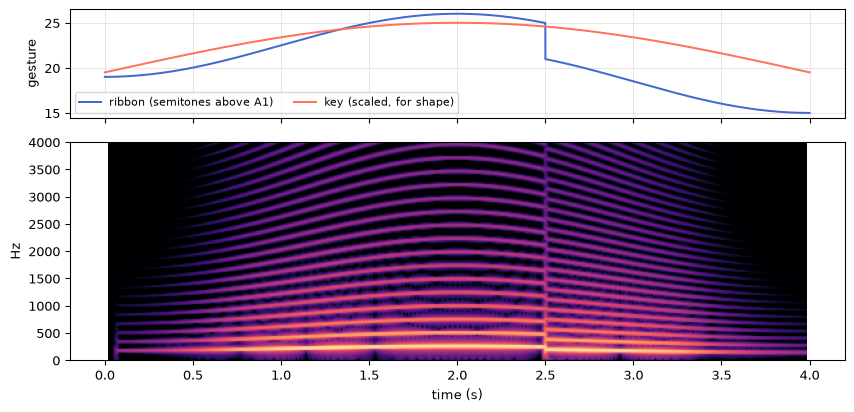

peak 0.586, rms 0.2127


In [11]:
n = int(sr * 4.0)
t = np.arange(n) / sr
# a hand: up a fifth, back down a third, with the key swelling under it
ribbon = 19.0 + 7.0 * (0.5 - 0.5 * np.cos(2 * np.pi * 0.25 * t)) - 4.0 * (t > 2.5)
key = 0.45 + 0.55 * np.clip(np.sin(np.pi * t / 4.0), 0, 1)

v = tap.Ondes(sr, smooth_ms=2.0, drive=2.5, level=0.5)
y = v.process(ribbon=ribbon, key=key)

fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})
axes[0].plot(t, ribbon, color=C[0], lw=1.5, label="ribbon (semitones above A1)")
axes[0].plot(t, key * 10 + 15, color=C[2], lw=1.5, label="key (scaled, for shape)")
axes[0].legend(fontsize=8, ncol=2); axes[0].set_ylabel("gesture")
dither = 1e-9 * np.sin(2 * np.pi * 7000.0 * t)  # so the silent lead-in is not log(0)
axes[1].specgram(y + dither, NFFT=2048, Fs=sr, noverlap=1536, cmap="magma", vmin=-120, vmax=-20)
axes[1].set_ylim(0, 4000); axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("Hz")
axes[1].grid(False)
plt.tight_layout()
plt.show()

print(f"peak {np.abs(y).max():.3f}, rms {np.sqrt((y**2).mean()):.4f}")

## What this is, and what it is not

**Not a circuit solve.** The paper's full port-Hamiltonian model runs at 768 kHz and their plugin
costs 85 % of a laptop core; it is passive by construction. This kernel is that model's *own*
published reductions plus its published component values: the oscillators replaced by their
closed-form envelope (exactly, as §2 shows), the stages reduced to static load-line curves with
first-order conditioning and equalization filters standing in for their reactive coupling.

**No waveform registers.** The real instrument has switchable timbres whose filter shapes are not
in any source obtained here. Leipp (*Bulletin du GAM* n°60, 1972) and Laurendeau's monograph are
where to look next. Inventing them would be the one thing this file is careful not to do.

**No diffuseur.** That is `tap.palme~` and `tap.metallique~` — patch one after this object, which
is how the instrument works anyway. `radiohead_render`'s `ondes_diffuseurs` scenario is the whole
thing wired together.

**One instrument's valves.** The parameter sets are a fit to No. 169's tubes, and tube-to-tube
spread in 1930s valves is wide.